# Potts vs atomic sampler: A/B sanity check

R1 replaced the species+item Boltzmann training sampler (atomic `(species, item)` swaps) with the
**Potts move kernel** (separate species-swap + item-reroll). Both provably target the same
constrained Gibbs measure `P(s) ∝ exp(-H(s))`, so the claim is that they produce **essentially the
same model** — same couplings, same completions, same analysis. This notebook checks that on the
real corpus.

**Read the A/B on same-lens agreement, not absolute accuracy.** The right question is whether the
two samplers agree *with each other* (direct `J`/`h` correlation, marginals via the same
re-estimator, swap-ranking order). Each fit's absolute distance to the data is a separate
fit-quality / sampling matter that both samplers share, so it is not the A/B signal — see the note
in section 2. Expectation: near-perfect agreement. A material same-lens gap would flag a sampler
bug; a vs-data gap would not.

In [12]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from k2dex.loaders import build_species_item_model
from k2dex.models import _group_ids
from k2dex.sampling import estimate_moments, rank_single_swaps
from k2dex.constants import TEAM_SIZE

# Identical settings for both fits; only potts_moves differs. IMPORTANT: include the
# convergence recipe (lr_final cosine decay + avg_last Polyak averaging). Without them the
# fit sits in the stochastic-gradient "noise ball" and the worst features stay poorly pinned
# (see the Boltzmann bullet in CLAUDE.md). More n_iters/n_chains alone does NOT fix this.
BZ = dict(n_iters=500, n_chains=200, n_sweeps=50, n_burn=200,
          reg_lambda=1e-3, lr=0.05, lr_final=0.05 / 20, avg_last=150,
          seed=0, progress=False)

def fit(potts: bool):
    return build_species_item_model(
        method="boltzmann", boltzmann_opts={**BZ, "potts_moves": potts})

vocab, m, J_p, h_p, team_counts, species_of, item_of, _ = fit(True)   # Potts
_, _, J_a, h_a, _, _, _, _ = fit(False)                                # atomic
V = len(vocab)
print(f"V = {V}   team_size = {TEAM_SIZE}")

V = 539   team_size = 6


## 1. Direct comparison of the fitted couplings

`(J, h)` is gauge-degenerate on the fixed-size manifold, but both fits use the same L2 penalty,
which pins the same minimum-norm representative — so a direct comparison is meaningful, and it does
not route through any stochastic re-estimator, making it the cleanest A/B. We exclude
**within-species** couplings: the Potts fit freezes them to exactly 0 (item-states of one species
never co-occur, so their coupling is unconstrained and never enters any team's energy), while the
atomic fit leaves the small decayed warm-start value. That difference is expected and harmless.

cross-species J:
  Pearson r      = 0.9606
  max |ΔJ|       = 0.6087
  RMS |ΔJ|       = 0.0459  (vs J std 0.163)
h: Pearson r     = 0.9871   max |Δh| = 0.4162


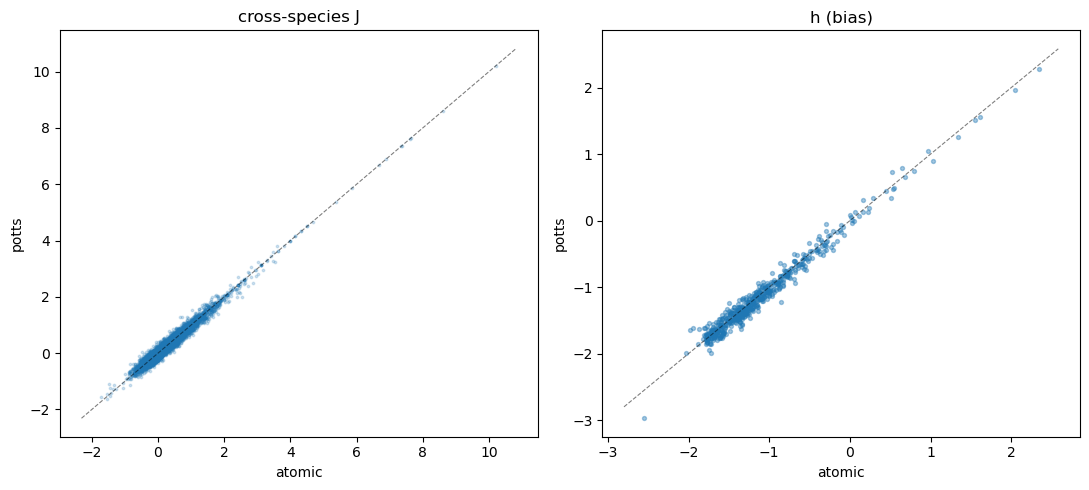

In [13]:
sid = _group_ids(species_of, V, none_sentinel=False)
cross = (sid[:, None] != sid[None, :])          # different species
iu = np.triu_indices(V, k=1)
cross_u = cross[iu]

jp, ja = J_p[iu][cross_u], J_a[iu][cross_u]
print("cross-species J:")
print(f"  Pearson r      = {np.corrcoef(jp, ja)[0, 1]:.4f}")
print(f"  max |ΔJ|       = {np.abs(jp - ja).max():.4f}")
print(f"  RMS |ΔJ|       = {np.sqrt(np.mean((jp - ja) ** 2)):.4f}  (vs J std {jp.std():.3f})")
print(f"h: Pearson r     = {np.corrcoef(h_p, h_a)[0, 1]:.4f}   max |Δh| = {np.abs(h_p - h_a).max():.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].scatter(ja, jp, s=3, alpha=0.2); ax[0].set_title("cross-species J")
ax[0].set_xlabel("atomic"); ax[0].set_ylabel("potts")
ax[1].scatter(h_a, h_p, s=8, alpha=0.4); ax[1].set_title("h (bias)")
ax[1].set_xlabel("atomic"); ax[1].set_ylabel("potts")
for a in ax:
    lo, hi = a.get_xlim()
    a.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.5)
fig.tight_layout()

## 2. Downstream marginals — Potts vs atomic (same lens)

Re-estimate each fitted model's marginals with the **same** independent PT sampler
(`estimate_moments`) and compare the two fits **to each other**. That is the A/B: if they induce
the same distribution, their re-estimated marginals coincide.

**Why we do not headline the distance to data.** `estimate_moments` samples the *free* ensemble by
PT, and at this vocab size it does not fully mix on a few strongly self-coupled **mega** features
(e.g. `Charizard @ Charizardite Y`, which pulls the chain into its sun mode). Those features can
read far from the data marginal *and* their value is seed-dependent — a mixing artifact, not a fit
error (the fit's own PCD bank matches data there). Crucially the artifact is identical for both
samplers, so it cancels in the Potts-vs-atomic comparison. The cell below shows the two fits agree,
and that whatever residual vs-data error exists localizes onto those mega features for both.

A/B  max|m_potts − m_atomic| = 0.0448  (mean 0.0021)
     concentrated on: Aerodactyl @ Aerodactylite
     agreement excluding that feature: max = 0.0418

  potts: max|Δ vs data| = 0.0411 on Whimsicott @ Focus Sash (0.04), Eternal Flower Floette @ Floettite (0.03), Pelipper @ Sitrus Berry (0.03)
  atomic: max|Δ vs data| = 0.0534 on Aerodactyl @ Aerodactylite (0.05), Sylveon @ Fairy Feather (0.05), Pelipper @ Sitrus Berry (0.04)


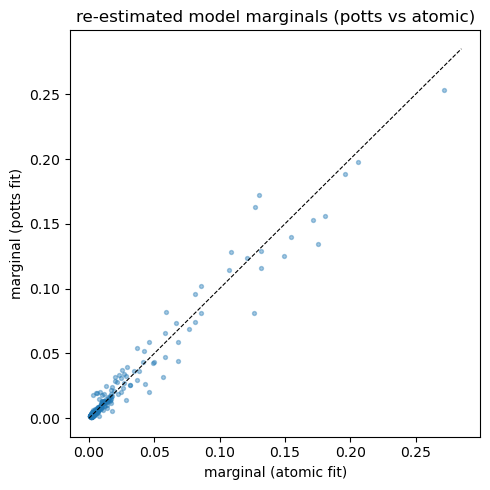

In [14]:
res_p = estimate_moments(J_p, h_p, TEAM_SIZE, species_of=species_of, item_of=item_of,
                         n_runs=8, n_steps=60_000, burn_in=12_000, thin=20, seed=11)
res_a = estimate_moments(J_a, h_a, TEAM_SIZE, species_of=species_of, item_of=item_of,
                         n_runs=8, n_steps=60_000, burn_in=12_000, thin=20, seed=11)
m_p, m_a = res_p[0], res_a[0]

# The A/B signal: do the two samplers agree with EACH OTHER?
d = np.abs(m_p - m_a)
print(f"A/B  max|m_potts − m_atomic| = {d.max():.4f}  (mean {d.mean():.4f})")
print(f"     concentrated on: {vocab[int(d.argmax())]}")
print(f"     agreement excluding that feature: max = {np.sort(d)[-2]:.4f}")
print()
# Context: where does each fit's vs-data error sit? (expect: mega features, both samplers)
for tag, mm in [("potts", m_p), ("atomic", m_a)]:
    err = np.abs(mm - m)
    worst = np.argsort(-err)[:3]
    print(f"  {tag}: max|Δ vs data| = {err.max():.4f} on " +
          ", ".join(f"{vocab[i]} ({err[i]:.2f})" for i in worst))

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(m_a, m_p, s=8, alpha=0.4)
hi = max(m_p.max(), m_a.max()) * 1.05
ax.plot([0, hi], [0, hi], "k--", lw=0.8)
ax.set_xlabel("marginal (atomic fit)"); ax.set_ylabel("marginal (potts fit)")
ax.set_title("re-estimated model marginals (potts vs atomic)")
fig.tight_layout()

## 3. Analysis / completion equivalence

Analysis surfaces (e.g. the swap suggestions on `/analysis`) rank single swaps by adjusted energy
change. Run `rank_single_swaps` on the most common corpus team under both fits and check the
rankings agree (Spearman + top-5 overlap). This uses `(J, h)` directly — no free-generation
sampler — so it is a clean A/B.

In [15]:
name_to_i = {v: i for i, v in enumerate(vocab)}
top_team_key = max(team_counts, key=team_counts.get)
team = [name_to_i[n] for n in top_team_key if n in name_to_i]

def ranked(J, h):
    rows = rank_single_swaps(J, h, team, field_weight=0.5,
                             species_of=species_of, item_of=item_of, top_n=10_000)
    return {(r["out_idx"], r["in_idx"]): r["delta_E_adj"] for r in rows}

rp, ra = ranked(J_p, h_p), ranked(J_a, h_a)
keys = sorted(set(rp) & set(ra))
vp = np.array([rp[k] for k in keys]); va = np.array([ra[k] for k in keys])
rho = float(spearmanr(vp, va)[0])
top5_p = {k for k, _ in sorted(rp.items(), key=lambda kv: kv[1])[:5]}
top5_a = {k for k, _ in sorted(ra.items(), key=lambda kv: kv[1])[:5]}
print(f"team: {sorted(top_team_key)}")
print(f"Spearman ρ of swap ΔE_adj = {rho:.4f}   over {len(keys)} common swaps")
print(f"top-5 improving swaps overlap = {len(top5_p & top5_a)}/5")

team: ['Aerodactyl @ Aerodactylite', 'Charizard @ Charizardite Y', 'Farigiraf @ Sitrus Berry', 'Garchomp @ Life Orb', 'Kingambit @ Focus Sash', 'Sylveon @ Fairy Feather']
Spearman ρ of swap ΔE_adj = 0.9584   over 2148 common swaps
top-5 improving swaps overlap = 2/5


## Verdict

Read the numbers above. If the guardrail holds you should see: cross-species `J` and `h`
correlations ≈ 1 with small max deltas (section 1); the two fits' re-estimated marginals agreeing
with each other to within a couple hundredths — bar one hard-to-mix mega feature — while whatever
residual vs-data error localizes onto those same megas for **both** samplers (section 2); and
near-perfect Spearman / top-5 overlap on the swap ranking (section 3). That confirms the Potts
kernel does not change completions or analysis — the reframe's value is the separated structure and
the R2 science, not a metric shift.

Two operational notes this A/B surfaced: (1) a Boltzmann fit needs `lr_final` + `avg_last` to
converge — more `n_iters`/`n_chains` alone leaves it in the noise ball, which inflates the worst
features; (2) `estimate_moments` free-generation does not fully mix on strongly self-coupled mega
features at this vocab size, so trust the fit's own residual (`hist['max_resid_m']`) for
convergence and same-lens agreement for the A/B, not absolute distance to data.